In [33]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import json


from tensorflow.keras import Model
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


# GPU: bardziej stabilnie
gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass
tf.config.optimizer.set_jit(False)  # wyłącz XLA, jeśli robił problemy

import sys
sys.path.append("/home/ciona/projects/RCOLM/data_models/MyModels/")
from mymodels import MyModels
tf.config.set_visible_devices([], 'GPU')
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"   # całkowicie wyłącz GPU

In [47]:
class MLP_gtzan:

    #method gets dataset_path and it splits it to train and test tables 
    @staticmethod
    def train_test_split_gtzan(gtzan_path, test_size=0.33, random_state=42,
                               extensions={'.png', '.jpg', '.jpeg', '.bmp'}):
        gtzan_root = Path(gtzan_path)
        if not gtzan_root.exists():
            raise FileNotFoundError(f"Ścieżka nie istnieje: {gtzan_root}")

        X, y = [], []
        for genre_dir in sorted([p for p in gtzan_root.iterdir() if p.is_dir() and not p.name.startswith('.')]):
            genre = genre_dir.name
            for img_path in sorted(genre_dir.iterdir()):
                if img_path.is_file() and img_path.suffix.lower() in extensions:
                    X.append(str(img_path))
                    y.append(genre)

        if not X:
            raise ValueError("Nie znaleziono żadnych obrazów z podanymi rozszerzeniami.")

        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        genre_names = list(le.classes_)

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded,
            test_size=test_size,
            random_state=random_state,
            stratify=y_encoded
        )
        # bezpieczniejszy podgląd
        print(X_train[0], X_test[0], y_test[0])
        return X_train, X_test, y_train, y_test, genre_names

    #method takes path to image directory and then preprecossing it to fit into model
    @staticmethod
    def load_and_preprocess_images(image_paths, target_size=(128, 128)):
        data = []
        for path in image_paths:
            with Image.open(path) as img:
                img = img.convert('RGB').resize(target_size)
                arr = np.asarray(img, dtype=np.float32) / 255.0
                data.append(arr)
        return np.stack(data, axis=0)


    #method for training model on augmented GTZAN dataset 
    @staticmethod
    def CNN_train(X_train, X_test, y_train, y_test, genre_names, model):
        # podgląd
        n_show = min(20, len(X_train))
        plt.figure(figsize=(10, 10))
        for i in range(n_show):
            plt.subplot(5, 5, i + 1)
            plt.xticks([]); plt.yticks([]); plt.grid(False)
            with Image.open(X_train[i]) as img:
                plt.imshow(img)
            plt.xlabel(genre_names[y_train[i]])
        plt.tight_layout(); plt.show()

        X_train_np = MLP_gtzan.load_and_preprocess_images(X_train)
        X_test_np  = MLP_gtzan.load_and_preprocess_images(X_test)
        y_train_np = np.asarray(y_train)
        y_test_np  = np.asarray(y_test)

        optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)

        callbacks = [
            tf.keras.callbacks.ModelCheckpoint("best.weights.h5", monitor="val_loss",
                                            save_best_only=True, save_weights_only=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                                patience=3, min_lr=1e-6),
            tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8,
                                            restore_best_weights=True)
        ]

        # softmax -> from_logits=False
        model.compile(
            optimizer=optimizer,
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=['accuracy']
        )

        history = model.fit(
            X_train_np, y_train_np,
            epochs=60,
            batch_size=32,
            validation_data=(X_test_np, y_test_np),
            callbacks=callbacks
        )



        plt.figure(figsize=(8, 6))
        plt.plot(history.history['accuracy'], label='Train')
        plt.plot(history.history['val_accuracy'], label='Val')
        plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Training & Validation')
        plt.legend(); plt.grid(True); plt.show()
        model.summary()
        return model, history

    #MODEL HANDLERS


    # this method takes trained model, classes and save directory. Then it saves the model 
    @staticmethod
    def save_model(model, genre_names, save_dir, image_size=(128, 128)):
        """Zapisuje model Keras + metadane do katalogu."""
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

        # model
        model_path = save_dir /"model.keras"
        model.save(model_path)

        # metadane
        meta = {
            "genre_names": list(genre_names),
            "image_width": image_size[0],
            "image_height": image_size[1],
            "expects_softmax": True
        }
        with open(save_dir / "meta.json", "w", encoding="utf-8") as f:
            json.dump(meta, f, ensure_ascii=False, indent=2)

        print(f"✅ Zapisano model do {save_dir.resolve()}")



    #this method takes dir where model is saved, and its returing it with metadata(classes)
    @staticmethod
    def load_model(save_dir):
        """Ładuje model + metadane"""
        save_dir = Path(save_dir)
        model = tf.keras.models.load_model(save_dir, compile=False)
        meta_path = save_dir / "meta.json"
        with open(meta_path, "r", encoding="utf-8") as f:
            meta = json.load(f)
        return model, meta


    # this method takes already saved model, metadata(classes) and melspec path,
    # then it's preprocessing png and predicting the output 
    @staticmethod
    def predict_from_path(model, meta, image_path, top_k=3):
        """Wczytuje jeden obraz, preprocess i zwraca top_k gatunków."""
        w, h = meta.get("image_width", 128), meta.get("image_height", 128)
        genre_names = meta["genre_names"]

    # preprocessing
        with Image.open(image_path) as img:
            img = img.convert("RGB").resize((w, h))
            arr = np.asarray(img, dtype=np.float32) / 255.0
        arr = np.expand_dims(arr, axis=0)  # batch=1

    # predykcja
        probs = model.predict(arr, verbose=0)[0]

        idx_sorted = np.argsort(probs)[::-1]
        results = [(genre_names[i], float(probs[i])) for i in idx_sorted[:top_k]]
        return results

/home/ciona/projects/RCOLM/data/converted_data/GTZAN/hiphop/hiphop.00078_TS.png /home/ciona/projects/RCOLM/data/converted_data/GTZAN/metal/metal.00029_pitch.png 6


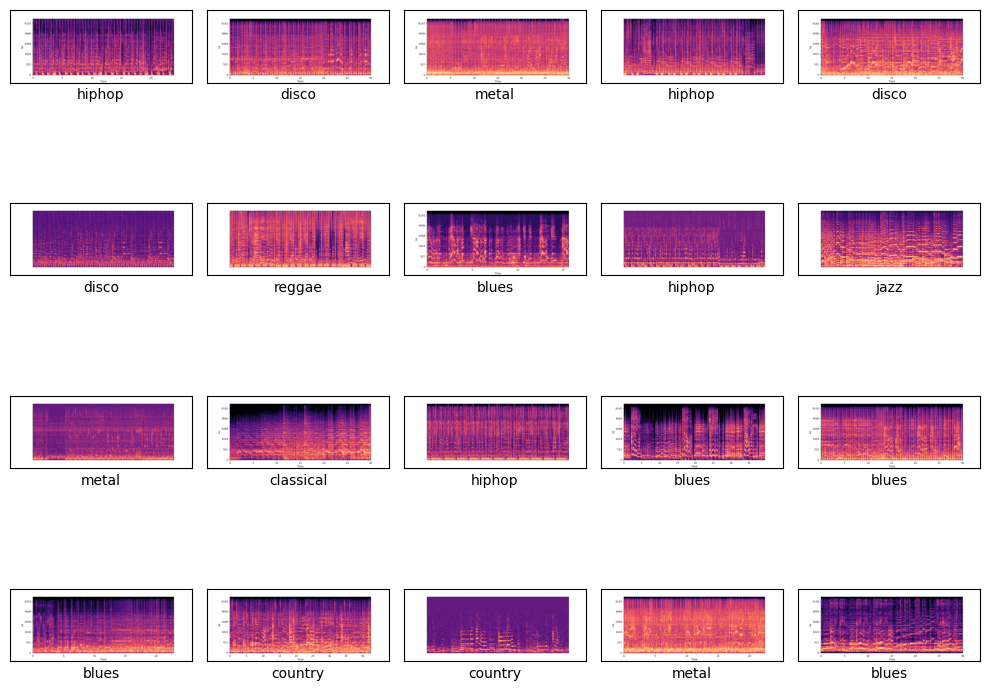

Epoch 1/5


/home/ciona/.venvs/jupynium/lib/python3.10/site-packages/keras/src/backend/tensorflow/nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - accuracy: 0.1872 - loss: 2.3297 - val_accuracy: 0.1457 - val_loss: 2.3020 - learning_rate: 3.0000e-04
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.2547 - loss: 2.0569 - val_accuracy: 0.1202 - val_loss: 2.3029 - learning_rate: 3.0000e-04
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.3030 - loss: 1.9172 - val_accuracy: 0.1083 - val_loss: 2.3037 - learning_rate: 3.0000e-04
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.3348 - loss: 1.8270 - val_accuracy: 0.1075 - val_loss: 2.2933 - learning_rate: 3.0000e-04
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.3721 - loss: 1.7382 - val_accuracy: 0.1521 - val_loss: 2.2661 - learning_rate: 3.0000e-04


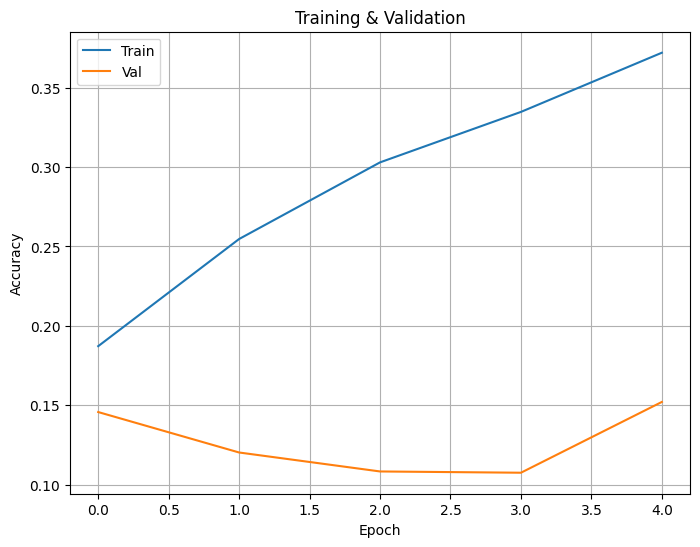

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_69 (Conv2D)              │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_69          │ (None, 126, 126, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_69 (Activation)      │ (None, 126, 126, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_69 (MaxPooling2D) │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_70          │ (None, 61, 61, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_70 (Activation)      │ (None, 61, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_70 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_71          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_71 (Activation)      │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_71 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_23     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,600 (287.50 KB)

 Trainable params: 24,458 (95.54 KB)

 Non-trainable params: 224 (896.00 B)

 Optimizer params: 48,918 (191.09 KB)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


/tmp/ipykernel_15183/397045645.py:38: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ciona/.venvs/jupynium/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


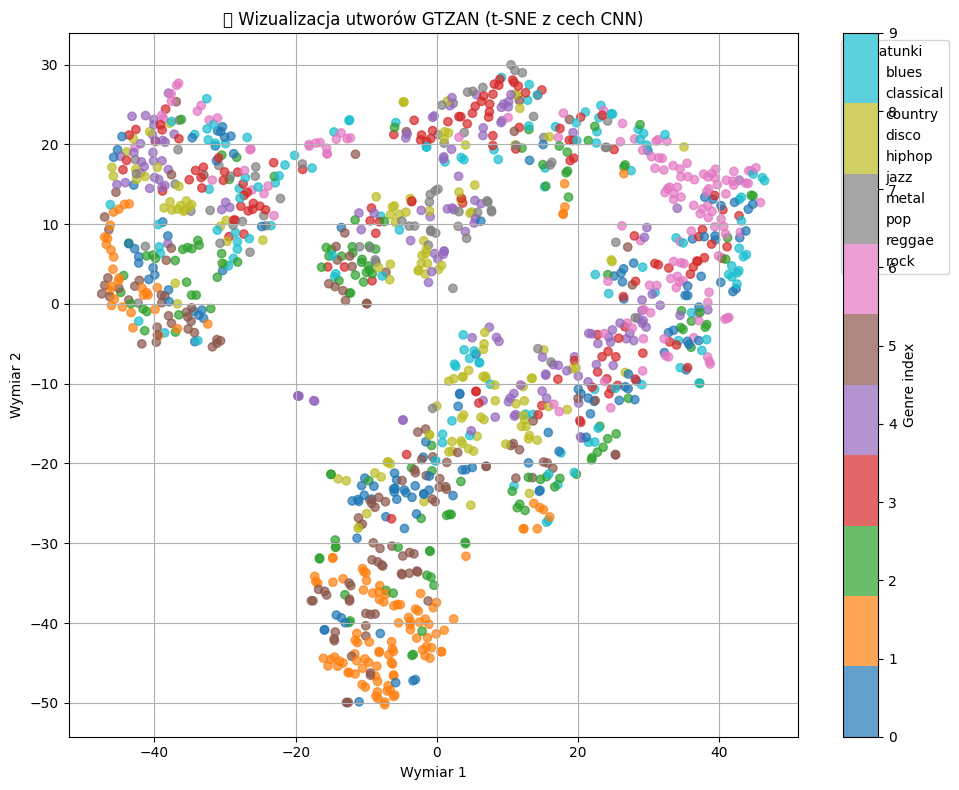

In [49]:
gtzan_path = "/home/ciona/projects/RCOLM/data/converted_data/GTZAN/"
save_dir =  "/home/ciona/projects/RCOLM/data_models/saved/gtzan_v1"
image_path = "/home/ciona/projects/RCOLM/tests/png/blue_train.png"

X_train, X_test, y_train, y_test, genre_names = MLP_gtzan.train_test_split_gtzan(gtzan_path)
num_classes = len(genre_names)
model = MyModels.CNN_model(num_classes)
model, history = MLP_gtzan.CNN_train(X_train, X_test, y_train, y_test, genre_names, model)


_ = model.predict(MLP_gtzan.load_and_preprocess_images(X_test[:1]), verbose=0)

# Stwórz model cech
feature_extractor = Model(
    inputs=model.inputs,
    outputs=model.layers[-3].output  # warstwa przed Dense
)

# Przetwórz dane testowe
X_test_np = MLP_gtzan.load_and_preprocess_images(X_test)
X_features = feature_extractor.predict(X_test_np, verbose=1)
y_labels = np.array(y_test)

# Redukcja wymiarów (PCA + t-SNE)
pca = PCA(n_components=50).fit_transform(X_features)
X_embedded = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto').fit_transform(pca)

# Scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_labels, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(len(genre_names)), label='Genre index')
handles, _ = scatter.legend_elements()
plt.legend(handles, genre_names, title="Gatunki", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("🎵 Wizualizacja utworów GTZAN (t-SNE z cech CNN)")
plt.xlabel("Wymiar 1")
plt.ylabel("Wymiar 2")
plt.grid(True)
plt.tight_layout()
plt.show()
#MLP_gtzan.save_model(model, genre_names, save_dir)
# model, meta = MLP_gtzan.load_model(save_dir)
# MLP_gtzan.predict_from_path(model, meta, image_path)